## Identify Customer Segments:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from preprocessor import AzdiasPreprocessor

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import set_config

import json

# magic word for producing visualizations in notebook
%matplotlib inline

pd.options.display.max_rows = None
pd.options.display.max_columns = None

# So that our sklearn estimators/transformers output a pandas dataframe
set_config(transform_output="pandas")

In [2]:
# CONSTANTS
DATA_AZDIAS = 'Udacity_AZDIAS_Subset.csv'
DATA_CUSTOMERS = "Udacity_CUSTOMERS_Subset.csv"
DATA_F_SUMMARY = 'Azdias_Feature_Summary.csv'
DATA_DICT = 'data_dictionary.json'

### Step 1: Load and Clean General Population Data:

Cleaning Function Defined Below:

In [3]:
def clean_data(df, preprocessor, is_customer_data=False):
    X_out = df.copy()

    X_out = preprocessor.clean_data(X_out, is_customer_data=is_customer_data)

    return X_out

Load the Population Demographics Data Again:

In [4]:
# Load the raw data and the feature dictionary
df_population_raw = pd.read_csv(DATA_AZDIAS, delimiter=";")

with open(DATA_DICT) as f:
    feature_dictionary = json.load(f)

df_population_raw.head()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,8,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1,0.0,0.0,1,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3,32.0,10.0,10.0,5.0,3.0,2.0,1,8,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2,0.0,0.0,2,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


Clean the Population Data, now using the preprocessor:

In [5]:
# Declare and initialize the preprocessor
az_preprocessor = AzdiasPreprocessor(
    data_source=DATA_AZDIAS,
    summary_source=DATA_F_SUMMARY
)

Learning from data in...Udacity_AZDIAS_Subset.csv
No pipeline parameter passed in. Building default pipeline...
Building cleaning pipeline...
No imputer and scaler parameters passed in.
Preprocessor initialized successfully...Ready to be used!


In [6]:
# Clean Population Data
df_population_clean = clean_data(df_population_raw, az_preprocessor, is_customer_data=False)
df_population_clean.head()

Cleaning Population Data...Fitting and Transforming...
[Pipeline] .. (step 1 of 6) Processing replace_missings, total=   1.9s
Dropping Features: ['KBA05_BAUMAX', 'ALTER_HH', 'AGER_TYP', 'KK_KUNDENTYP', 'GEBURTSJAHR', 'TITEL_KZ']
Dropped 6 features
[Pipeline] ..... (step 2 of 6) Processing drop_features, total=   0.7s
Kept 797961 rows, dropped 93260 rows
[Pipeline] ........ (step 3 of 6) Processing split_data, total=   0.3s
Dropping Features: ['SOHO_KZ', 'CAMEO_DEUG_2015', 'NATIONALITAET_KZ', 'LP_LEBENSPHASE_GROB', 'LP_FAMILIE_GROB', 'LP_STATUS_GROB', 'PLZ8_BAUMAX']
Dropped 7 features
[Pipeline] .. (step 4 of 6) Processing drop_categorical, total=   0.6s
MixedFeatureEngineer Encoding...
MixedFeatureEngineer Encoded PRAEGENDE_DECADE from PRAEGENDE_JUGENDJAHRE
MixedFeatureEngineer Encoded PRAEGENDE_MOVEMENT from PRAEGENDE_JUGENDJAHRE
MixedFeatureEngineer Dropped PRAEGENDE_JUGENDJAHRE
MixedFeatureEngineer Encoded CAMEO_WEALTH from CAMEO_INTL_2015
MixedFeatureEngineer Encoded CAMEO_LIFESTAG

,ALTERSKATEGORIE_GROB,ANREDE_KZ,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,ANZ_PERSONEN,ANZ_TITEL,ARBEIT,BALLRAUM,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan,CAMEO_LIFESTAGE,CAMEO_WEALTH,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,EWDICHTE,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,FINANZ_ANLEGER,FINANZ_HAUSBAUER,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_UNAUFFAELLIGER,FINANZ_VORSORGER,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GEBAEUDETYP_RASTER,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_nan,GREEN_AVANTGARDE,HEALTH_TYP,HH_EINKOMMEN_SCORE,INNENSTADT,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,KBA13_ANZAHL_PKW,KKK,KONSUMNAEHE,LP_AGE_CLASS,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_nan,LP_INCOME_LEVEL,LP_IS_HOMEOWNER,LP_IS_INDEPENDENT,LP_LIFE_STAGE_1.0,LP_LIFE_STAGE_2.0,LP_LIFE_STAGE_3.0,LP_LIFE_STAGE_4.0,LP_LIFE_STAGE_5.0,LP_LIFE_STAGE_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_nan,MIN_GEBAEUDEJAHR,MOBI_REGIO,ONLINE_AFFINITAET,ORTSGR_KLS9,OST_WEST_KZ,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_GBZ,PLZ8_HHZ,PRAEGENDE_DECADE,PRAEGENDE_MOVEMENT,REGIOTYP,RELAT_AB,RETOURTYP_BK_S,SEMIO_DOM,SEMIO_ERL,SEMIO_FAM,SEMIO_KAEM,SEMIO_KRIT,SEMIO_KULT,SEMIO_LUST,SEMIO_MAT,SEMIO_PFLICHT,SEMIO_RAT,SEMIO_REL,SEMIO_SOZ,SEMIO_TRADV,SEMIO_VERT,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,VERS_TYP,WOHNDAUER_2008,WOHN_IS_RURAL,WOHN_NEIGHBORHOOD_QUALITY,WOHN_NEW_BUILDING,W_KEIT_KIND_HH,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,1.0,2,11.0,0.0,2.0,0.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,5,5,1,5,4,2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,3.0,6.0,8.0,0.0,0.0,0.0,2.0,1.0,963.0,2.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1992.0,1.0,3.0,5.0,1.0,2.0,3.0,2.0,1.0,4.0,5.0,1990.0,1.0,3.0,4.0,1.0,7,2,4,4,4,3,2,3,7,6,4,5,6,1,0.0,0.0,0.0,1.0,0.0,2.0,9.0,NaN,4.0,NaN,3.0,0.0,0.0,0.0,0.0,1.0,0.0
1,3.0,2,10.0,0.0,1.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0

## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [7]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.
df_population_clean.isna().sum().sum()

np.int64(4130924)

We still have NaN values. We will need to use ```SimpleImputer()``` to replace the remaining missing values.

## Imputation and Scaling Strategy

Based on the feature types identified, here are the recommended imputation and scaling strategies:

| Feature Type                  | Count | Imputation Strategy | Recommended Imputer                       | Scaling Strategy       | Recommended Scaler | Notes                                            |
|-------------------------------|-------|---------------|-------------------------------------------|------------------------|-------------------|--------------------------------------------------|
| **binary**                    | 8     | Most frequent | `SimpleImputer(strategy='most_frequent')` | None needed            | None | Binary features (0/1) don't need scaling         |
| **non_numerical_categorical** | 1     | Most frequent | `SimpleImputer(strategy='most_frequent')` | None (already encoded) | None | OST_WEST_KZ already ordinal encoded to 0/1       |
| **ordinal**                   | 54    | Median | `SimpleImputer(strategy='median')`        | Median                 | `StandardScaler()` | Median preserves order                           |
| **numerical**                 | 6     | Median | `SimpleImputer(strategy='median')`        | Median                 | `StandardScaler()` | Median prevents issues with skewed distributions |
| **interval**                  | 1     | Median | `SimpleImputer(strategy='mean')`          | Median                 | `StandardScaler()` | Treat like ordinal                               |
| **one-hot encoded**           | 118   | Zero (already one-hot) | None needed                               | None                   | None | One-hot encoded -> NaN becomes all zeroes        |

### Key Principles Applied

1. **Median > Mean** for skewed data and count variables (more robust to outliers)
2. **StandardScaler** for features going into PCA/clustering (assumes approximately normal distribution)
3. **No scaling for binary** features (already 0/1)
4. **Most frequent for categorical** (preserves mode)
5. **One-hot encoded features** need no imputation (missing values already handled during encoding)


In [8]:
df_population_scaled = az_preprocessor.impute_and_scale_data(df_population_clean)
print(df_population_scaled.info())
df_population_scaled.head()

Imputing and Scaling Data...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797961 entries, 0 to 797960
Columns: 188 entries, WOHN_NEW_BUILDING to ZABEOTYP_6
dtypes: float64(188)
memory usage: 1.1 GB
None


,WOHN_NEW_BUILDING,VERS_TYP,PRAEGENDE_MOVEMENT,LP_IS_INDEPENDENT,LP_IS_HOMEOWNER,ANREDE_KZ,GREEN_AVANTGARDE,WOHN_IS_RURAL,OST_WEST_KZ,PLZ8_ANTG1,REGIOTYP,RETOURTYP_BK_S,FINANZ_VORSORGER,CAMEO_WEALTH,GEBAEUDETYP_RASTER,WOHN_NEIGHBORHOOD_QUALITY,SEMIO_PFLICHT,FINANZ_SPARER,PLZ8_GBZ,SEMIO_ERL,HH_EINKOMMEN_SCORE,PLZ8_HHZ,FINANZ_HAUSBAUER,HEALTH_TYP,PLZ8_ANTG3,LP_INCOME_LEVEL,KBA05_ANTG3,ALTERSKATEGORIE_GROB,SEMIO_KRIT,LP_AGE_CLASS,KBA05_ANTG1,KKK,SEMIO_SOZ,MOBI_REGIO,FINANZ_MINIMALIST,SEMIO_KAEM,SEMIO_DOM,EWDICHTE,SEMIO_KULT,ARBEIT,ONLINE_AFFINITAET,W_KEIT_KIND_HH,KBA05_ANTG4,BALLRAUM,PLZ8_ANTG2,PLZ8_ANTG4,SEMIO_LUST,SEMIO_REL,KBA05_GBZ,KBA05_ANTG2,INNENSTADT,RELAT_AB,SEMIO_VERT,SEMIO_RAT,WOHNDAUER_2008,SEMIO_TRADV,CAMEO_LIFESTAGE,SEMIO_MAT,KONSUMNAEHE,FINANZ_UNAUFFAELLIGER,SEMIO_FAM,FINANZ_ANLEGER,ORTSGR_KLS9,ANZ_TITEL,KBA13_ANZAHL_PKW,ANZ_HAUSHALTE_AKTIV,ANZ_PERSONEN,ANZ_HH_TITEL,MIN_GEBAEUDEJAHR,PRAEGENDE_DECADE,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_nan,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_nan,LP_LIFE_STAGE_1.0,LP_LIFE_STAGE_2.0,LP_LIFE_STAGE_3.0,LP_LIFE_STAGE_4.0,LP_LIFE_STAGE_5.0,LP_LIFE_STAGE_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_nan,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,0.0,0.922935,0.530442,0.0,0.0,0.957933,-0.530442,0.0,0.517442,-0.256546,-0.857803,-1.686261,-1.040689,1.186211,-0.799725,0.940197,1.518634,1.537983,0.574231,-1.435418,1.026614,1.430429,1.339234,1.096551,0.403008,-0.598124,-0.594928,-1.766616,-0.312140,0.057955,-1.070636,-0.791555,0.443126,-1.411325,-1.494605,-0.157563,1.339260,-0.546630,-0.578196,-0.166432,0.171125,-0.671581,2.730470,0.845786,0.211996,0.406638,-1.109902,0.002910,-1.65918,-1.030742,1.701148,0.684853,-1.684601,1.274181,0.56721,1.288950,-1.266976,-0.463834,-1.304714,0.958818,-0.059306,1.466048,-0.127075,-0.060412,1.020583,0.171607,0.234378,-0.125139,-0.383241,1.172911,-0.117408,-0.071609,-0.073753,-0.123087,-0.079925,-0.129933,-0.140671,-0.157937,-0.214419,-0.115707,-0.095133,-0.213432,-0.211945,-0.208199,-0.107087,-0.252472,-0.104194,-0.081925,-0.124662,-0.114657,-0.112283,-0.138144,-0.067141,-0.07346,-0.092771,-0.276497,-0.137564,-0.087573,-0.143531,-0.082481,-0.212251,-0.177988,-0.107195,-0.082026,-0.0

Imputing and Scaling done, check:

In [9]:
print(f"Number of NaN values in Population Data: {df_population_scaled.isna().sum().sum()}")
df_population_scaled.describe().mean(axis=1)

Number of NaN values in Population Data: 0


count    7.979610e+05
mean    -1.717375e-16
std      9.787240e-01
min     -7.372284e-01
25%     -4.201042e-01
50%     -1.322532e-01
75%      1.678237e-01
max      1.042398e+01
dtype: float64

After scaling, the average Mean across all features is ~1 and the average STD is ~0.

### Discussion 2.1: Apply Feature Scaling

We used an imputer to replace NaN values and then a StandardScaler() to scale all the data. As can be seen in the summary above, mean ≈ 0 and STD ≈ 1, which verifies our data is properly scaled.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

#### Step 2.2.1: Use PCA to Apply Principal Component Analysis:

We first start by applying PCA without any parameters, so all components are computed:

In [10]:
# Apply PCA to the data.
# Check number of components that is at least half the number of features
# We keep as reference to compare later
n_comps = int(df_population_scaled.shape[1] / 2)
print(f"Number of components: {n_comps}")

# PCA without parameters
pca = PCA()
X_pca = pca.fit_transform(df_population_scaled)

Number of components: 94


Next, we set our threshold:

In [11]:
# Set our explained variance threshold
VARIANCE_THRESHOLD = 85

Next, we plot:

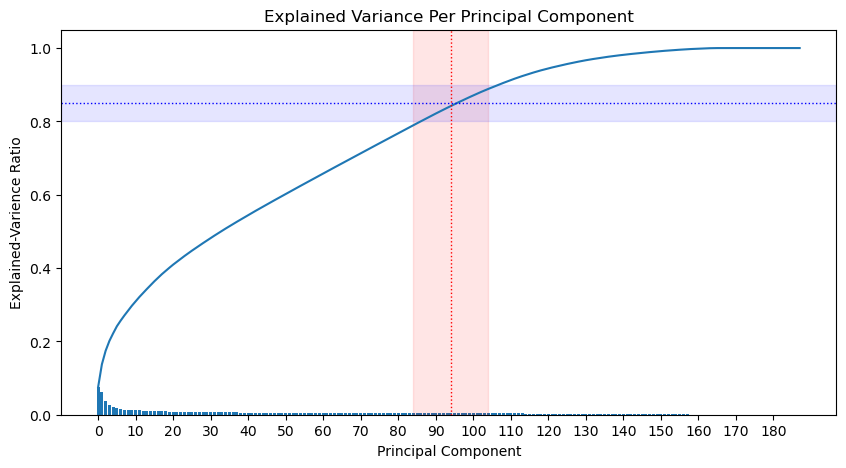

In [12]:
# Get the indexes
n_components = len(pca.explained_variance_ratio_)
component_idxs = np.arange(n_components)

# Get the explained variance ratios
variance_ratios = pca.explained_variance_ratio_

plt.figure(figsize=(10, 5))

# Get the cumulative sums
cumulative_variance = np.cumsum(variance_ratios)

# Scree Plot:
plt.bar(component_idxs, variance_ratios)
plt.plot(component_idxs, cumulative_variance)

plt.axvline(x=n_comps, linestyle=':', linewidth=1, color='r')  # Approx. N_components calculated above
plt.axvspan(n_comps - 10, n_comps + 10, alpha=0.10, color='r') # Shade the region of +/- 10 components

plt.axhline(y=VARIANCE_THRESHOLD / 100, linestyle=':', linewidth=1, color='b')  # Our Threshold
plt.axhspan(.80, .90, alpha=0.10, color='b') # Shade the of 80-90% explained variance ratio (our goal)

plt.xlabel("Principal Component")
plt.xticks(np.arange(0, n_comps * 2, 10))

plt.ylabel("Explained-Varience Ratio")
plt.title('Explained Variance Per Principal Component')
plt.show()

So, as we can see, for retaining 80-90% of information from the original data, dimensionally reduce to 85 to 105 components .

In [13]:
# Determine number of components to reach 85% variance
# Chose 85% because we want to retain 80-90% of the information from the original data
n_components = 0

# iterate over the cumulative variances
for n in range(len(cumulative_variance)):
    # Stop when we reach 85 and print the value
    if cumulative_variance[n] * 100 >= 85:
        n_components = n
        break

print(f"Number of components to reach at least 85% variance: {n_components}")

Number of components to reach at least 85% variance: 96


And thus, we will reduce to 96 components. We re-apply PCA to get a final model with the 96 components:

In [14]:
# Re-apply PCA to the data while selecting for number of components to retain.
# Use random_state=42 to ensure reproducible results
pca_final = PCA(n_components=n_components, random_state=42)
X_pca = pca_final.fit_transform(df_population_scaled)
X_pca.head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15,pca16,pca17,pca18,pca19,pca20,pca21,pca22,pca23,pca24,pca25,pca26,pca27,pca28,pca29,pca30,pca31,pca32,pca33,pca34,pca35,pca36,pca37,pca38,pca39,pca40,pca41,pca42,pca43,pca44,pca45,pca46,pca47,pca48,pca49,pca50,pca51,pca52,pca53,pca54,pca55,pca56,pca57,pca58,pca59,pca60,pca61,pca62,pca63,pca64,pca65,pca66,pca67,pca68,pca69,pca70,pca71,pca72,pca73,pca74,pca75,pca76,pca77,pca78,pca79,pca80,pca81,pca82,pca83,pca84,pca85,pca86,pca87,pca88,pca89,pca90,pca91,pca92,pca93,pca94,pca95
0,-5.136773,3.310263,3.134226,0.461790,-0.646308,0.197461,-2.196242,2.130266,1.984876,0.527717,-1.900194,4.084152,2.671512,-3.783252,-0.533413,0.720095,0.646618,-1.988728,1.034369,-0.359725,-1.467842,-0.099352,1.344835,-2.510589,-0.146773,1.114429,2.114434,2.040450,2.633965,-0.037408,-1.744358,0.048692,-2.900396,-1.798263,-0.481241,-1.717921,-0.254167,0.756822,-0.153335,1.724403,-0.092096,0.257652,-1.100146,0.050845,0.365632,1.635266,-0.455854,0.399639,-2.411245,-0.813529,-2.282274,1.664395,-0.522390,1.631886,-0.578238,2.308795,-0.209951,1.089061,-1.555042,-0.988785,0.645848,1.489390,-0.168641,-0.845552,0.066502,-0.371793,0.565251,0.036957,0.345699,0.275044,-0.110208,0.417307,0.326286,0.198559,0.610204,-0.139867,0.358281,-0.364651,0.514060,0.236765,0.016927,-1.519363,-0.773414,0.366152,-1.164892,1.089262,0.092966,-0.996450,-0.968247,1.586096,1.839695,-0.675717,0.005855,-0.695501,0.368516,-0.211614
1,0.069100,0.898673,3.156602,1.858203,3.680316,-0.002225,-0.896375,-0.707785,-0.391641,-0.718721,0.390895,1.103897,-1.419861,0.043398,-0.391395,-0.994938,-1.848910,0.335153,-0.345290,-1.782918,-0.582641,-0.350166,0.115309,-1.779468,-0.322999,0.797395,-1.211927,-0.096480,-1.134771,0.192777,0.873070,-0.079233,-2.508034,0.830399,1.922346,0.164779,-0.587267,1.656444,-2.233674,0.089125,1.771048,0.246824,-0.958939,1.414841,-1.067767,-0.872920,-1.061950,0.412673,-0.139807,0.802965,-0.082567,-0.285625,-0.509320,0.989253,-0.786818,-0.505819,0.212105,0.606341,0.050565,-0.693174,-0.087896,0.369015,-0.158327,-0.534765,-0.045302,0.550276,-0.141543,0.119502,-0.088759,0.012187,-0.169059,-0.224281,-0.120672,0.252332,-0.152369,0.116719,-0.230910,0.177710,-0.214410,-0.331234,-0.355370,0.017547,0.090521,-0.149136,-0.266992,0.591861,0.459362,0.469044,-0.228738,0.539653,0.272274,0.551992,1.141595,0.943176,-0.166466,-2.281904
2,4.293001,-1.266060,1.440146,-2.206440,-0.533907,3.088913,0.813445,0.197884,0.427617,0.177918,-0.385100,-2.193922,2.099355,0.333852,0.678618,0.661329,2.191188,0.911668,0.280318,-0.139924,-1.425256,2.411305,0.569269,-1.707492,-1.301907,1.174570,0.605602,-2.373766,-0.162295,0.753207,-1.264828,0.947910,-0.003228,0.201592,-0.009305,-0.852808,-0.653513,0.372626,-0.568229,0.002813,-0.191762,1.693458,1.091406,1.942507,-0.024527,1.098852,-1.843501,-1.064463,0.378501,-2.058709,0.029232,-2.018051,0.662061,-1.273191,-0.279483,-1.580047,-1.585996,-0.166265,0.679247,1.127129,-0.659989,-0.138159,1.428332,0.426869,-0.692446,2.617340,-0.312361,1.198510,2.116636,-0.047889,1.272396,-0.577844,1.358379,-1.080870,-1.697668,-0.273034,-0.246185,-0.631500,-0.591309,0.260408,-1.751858,-1.654966,-0.222999,0.893548,-0.626911,-0.112708,-1.747453,-0.390131,1.369967,-0.799338,-0.877382,0.850437,0.568396,1.417521,0.381859,0.028851
3,0.133322,-0.260870,-3.145989,1.803343,-3.319425,-0.600224,-0.651759,-1.965870,0.522105,-3.452149,-0.536305,1.297472,0.258594,2.216955,0.636203,-0.928680,-1.754532,1.924719,-0.324403,-1.377766,-0.027300,-0.669990,-0.978113,1.329372,-0.534521,-1.202935,-0.385010,0.853226,-0.001417,-0.974586,-0.249793,1.211143,-1.135559,0.884097,1.900723,-1.546297,-0.078897,0.819716,2.600007,-0.760652,1.567216,-0.164176,-1.199483,0.174993,1.443148,0.657480,-1.656382,0.496088,0.945551,0.337152,-0.112344,0.342320,0.259042,-0.609920,-0.484914,-0.398189,0.451099,-0.913016,0.060646,0.186780,-0.272753,-0.032342,0.162266,-0.082186,0.257920,-0.241187,-0.065285,-0.206194,-0.053504,0.093025,-0.142058,0.10921

### Discussion 2.2: Perform Dimensionality Reduction

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding dimensionality reduction. How many principal components / transformed features are you retaining for the next step of the analysis?)

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [15]:
# Investigate a sample of the components
print(f"pca_f.components_.shape: {pca_final.components_.shape}")
# Visualize a sample of the data
pca_final.components_[:5, :10]

pca_f.components_.shape: (96, 188)


array([[ 0.00000000e+00, -2.92932621e-02, -1.10496339e-01,
        -3.33066907e-16,  1.11022302e-16, -1.31907292e-02,
         1.10496339e-01, -1.73472348e-18,  4.25846676e-02,
         1.85284152e-01],
       [-0.00000000e+00, -2.41531312e-02, -2.85121253e-02,
        -0.00000000e+00, -3.33066907e-16, -3.89203630e-02,
         2.85121253e-02,  3.46944695e-18,  2.53263525e-02,
         8.47899650e-02],
       [ 0.00000000e+00,  8.09363219e-04,  6.28737726e-02,
        -6.00648004e-17, -5.55111512e-17,  3.48396234e-01,
        -6.28737726e-02,  8.32667268e-17,  4.34239677e-03,
         4.52668184e-02],
       [-0.00000000e+00,  1.68074296e-02, -2.96463372e-01,
        -7.28583860e-17,  1.66533454e-16,  7.15551574e-02,
         2.96463372e-01,  1.11022302e-16,  5.60148167e-02,
        -8.52636805e-02],
       [-0.00000000e+00, -6.74295617e-03, -1.37350273e-01,
         8.67361738e-18, -9.71445147e-17,  3.58553500e-02,
         1.37350273e-01,  9.71445147e-17,  1.00308118e-01,
         5.

We will use a dictionary to keep track of PC1, PC2 and PC3:

In [16]:
# Uncomment and Run this cell do clear prominent features dictionary
prominent_features = {0:{}, 1:{}, 2:{}}

Now we map weights to features:

In [17]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.
def map_component_weights(pca, df, pf_dict, pc_no, n_show=5):

    # Get the feature names and the weights
    feature_names = df.columns
    weights = pca.components_[pc_no]

    # Sanity Check
    assert len(feature_names) == len(weights)

    # Create a list of (feature_name, weight) tuples, sorted by weight from highest to lowest.
    weight_mapping = sorted(zip(feature_names, weights), key=lambda x: x[1], reverse=True)

    # We will only show the top and bottom values, given by n_show
    mapping_to_show = weight_mapping[:n_show] + weight_mapping[-n_show:]

    print(f"Printing mapping for PC{pc_no+1}, showing the {n_show} top and bottom: ")

    for feature, weight in mapping_to_show:

        # Add the information to the prominent features dictionary
        # for the given PC number and feature
        pf_dict[pc_no][feature] = round(float(weight.item()), 4)

        # Print results
        # Try to get description
        try:
            description = feature_dictionary[feature]["desc"][:50]
        except KeyError:
            description = "No description available"

        print(f"Feature Name: {feature:<20} | {description:<50} | Weight: {weight:>8.4f}")

Map PC1:

In [18]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
map_component_weights(pca_final, df_population_scaled, prominent_features, pc_no=0)

Printing mapping for PC1, showing the 5 top and bottom: 
Feature Name: FINANZ_MINIMALIST    | Financial typology: MINIMALIST (low financial inte | Weight:   0.2078
Feature Name: MOBI_REGIO           | Movement patterns                                  | Weight:   0.2075
Feature Name: KBA05_ANTG1          | Number of 1-2 family houses in the microcell (shar | Weight:   0.1920
Feature Name: PLZ8_ANTG1           | Number of 1-2 family houses in the PLZ8 region (sh | Weight:   0.1853
Feature Name: KBA05_GBZ            | Number of buildings in the microcell (category)    | Weight:   0.1827
Feature Name: ORTSGR_KLS9          | Size of community                                  | Weight:  -0.1558
Feature Name: PLZ8_ANTG4           | Number of 10+ family houses in the PLZ8 region (sh | Weight:  -0.1783
Feature Name: CAMEO_WEALTH         | No description available                           | Weight:  -0.1827
Feature Name: PLZ8_ANTG3           | Number of 6-10 family houses in the PLZ8 region (s

Map PC2:

In [19]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.
map_component_weights(pca_final, df_population_scaled, prominent_features, pc_no=1)

Printing mapping for PC2, showing the 5 top and bottom: 
Feature Name: PRAEGENDE_DECADE     | No description available                           | Weight:   0.2271
Feature Name: FINANZ_SPARER        | Financial typology: SPARER (money-saver)           | Weight:   0.2093
Feature Name: FINANZ_UNAUFFAELLIGER | Financial typology: UNAUFFAELLIGER (inconspicuous) | Weight:   0.2064
Feature Name: SEMIO_REL            | Personality typology: REL (religious)              | Weight:   0.1974
Feature Name: SEMIO_TRADV          | Personality typology: TRADV (traditional-minded)   | Weight:   0.1957
Feature Name: SEMIO_ERL            | Personality typology: ERL (event-oriented)         | Weight:  -0.1697
Feature Name: ZABEOTYP_3           | No description available                           | Weight:  -0.1963
Feature Name: LP_AGE_CLASS         | No description available                           | Weight:  -0.1979
Feature Name: FINANZ_VORSORGER     | Financial typology: VORSORGER (be prepared)      

Map PC3:

In [20]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.
map_component_weights(pca_final, df_population_scaled, prominent_features, pc_no=2)

Printing mapping for PC3, showing the 5 top and bottom: 
Feature Name: ANREDE_KZ            | Gender                                             | Weight:   0.3484
Feature Name: SEMIO_KAEM           | Personality typology: KAEM (combative attitude)    | Weight:   0.3198
Feature Name: SEMIO_DOM            | Personality typology: DOM (dominant-minded)        | Weight:   0.2881
Feature Name: SEMIO_KRIT           | Personality typology: KRIT (critical-minded)       | Weight:   0.2686
Feature Name: SEMIO_ERL            | Personality typology: ERL (event-oriented)         | Weight:   0.2115
Feature Name: FINANZTYP_5          | No description available                           | Weight:  -0.1335
Feature Name: SEMIO_KULT           | Personality typology: KULT (cultural-minded)       | Weight:  -0.2551
Feature Name: SEMIO_SOZ            | Personality typology: SOZ (socially-minded)        | Weight:  -0.2593
Feature Name: SEMIO_FAM            | Personality typology: FAM (family-minded)         

### Discussion 2.3: Interpret Principal Components

_"Since individual loadings are defined by a cosine function, they are limited to the range –1 (an angle of
rotation of 180◦ to +1 an angle of rotation of 0◦). The sign of the loading indicates how a variable
contributes to the principal component. A positive loading indicates that a variable contributes to some
degree to the principal component, and a negative loading indicates that its absence contributes to some
degree to the principal component. The larger a loading’s relative magnitude, the more important is its
presence or absence to the principal component."_

- https://cran.r-project.org/web/packages/LearnPCA/vignettes/Vig_04_Scores_Loadings.pdf

## Principal Component Analysis - Detailed Feature Interpretations

### PC1: Urbanization & Socioeconomic Geography

#### High Positive Scores

| Feature | Weight | Interpretation |
|---------|--------|-----------------------|
| **FINANZ_MINIMALIST** | +0.2078 |  |
| **MOBI_REGIO** | +0.2075 |  |
| **KBA05_ANTG1** | +0.1920 |  |
| **PLZ8_ANTG1** | +0.1853 |  |
| **KBA05_GBZ** | +0.1827 |  |

#### High Negative Scores

| Feature | Weight | Detailed Interpretation |
|---------|--------|------------------------|
| **HH_EINKOMMEN_SCORE** | -0.1889 |  |
| **PLZ8_ANTG3** | -0.1834 |  |
| **CAMEO_WEALTH** | -0.1827 |  |
| **PLZ8_ANTG4** | -0.1783 |  |
| **ORTSGR_KLS9** | -0.1558 |  |

**PC1 Summary**: This component...

---

### PC2: Life Stage & Cultural Orientation

#### High Positive Scores

| Feature | Weight | Detailed Interpretation |
|---------|--------|------------------------|
| **PRAEGENDE_DECADE** | +0.2271 |  |
| **FINANZ_SPARER** | +0.2093 |  |
| **FINANZ_UNAUFFAELLIGER** | +0.2064 |  |
| **SEMIO_REL** | +0.1974 |  |
| **SEMIO_TRADV** | +0.1957 |  |

#### High Negative Scores

| Feature | Weight | Detailed Interpretation |
|---------|--------|------------------------|
| **ALTERSKATEGORIE_GROB** | -0.2174 |  |
| **FINANZ_VORSORGER** | -0.2063 |  |
| **LP_AGE_CLASS** | -0.1979 |  |
| **ZABEOTYP_3** | -0.1963 |  |
| **SEMIO_ERL** | -0.1697 |  |

**PC2 Summary**: This component ...

---

### PC3:

#### High Positive Scores

| Feature | Weight | Detailed Interpretation |
|---------|--------|------------------------|
| **ANREDE_KZ** | +0.3484 |  |
| **SEMIO_KAEM** | +0.3198 |  |
| **SEMIO_DOM** | +0.2881 |  |
| **SEMIO_KRIT** | +0.2686 |  |
| **SEMIO_ERL** | +0.2115 |  |

#### High Negative Scores

| Feature | Weight | Detailed Interpretation |
|---------|--------|------------------------|
| **SEMIO_VERT** | -0.3218 |  |
| **SEMIO_FAM** | -0.2635 |  |
| **SEMIO_SOZ** | -0.2593 |  |
| **SEMIO_KULT** | -0.2551 |  |
| **FINANZTYP_5** | -0.1335 |  |

**PC3 Summary**: This component ...

---

#### Key Insights

1. (PC1):
2. (PC2):
3. (PC3):

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

**IMPORTANT NOTE**: Only run the next cells if you want to retrain and plot

In [21]:
TEST_CLUSTERS = True

#### Part 3.1.1: Perform KMeans to Different Cluster Counts:

We choose a range of clusters from 2 to 30, run KMeans and keep track of score, inertia, average distance from each point to it's assigned cluster's centroid, and the silhouette score.

In [22]:
# Define our cluster testing range and perform the test
k_range = np.arange(2, 31)

if TEST_CLUSTERS:
    inertias = [] # inertia (sum of squared distances to the closest cluster center)
    scores = [] # score (negative inertia)
    avg_distances = [] # intertia/number samples
    silhouette_scores = []

    # Over a number of different cluster counts...
    for k in k_range:
        # run k-means clustering on the data and...
        model = KMeans(n_clusters=k, random_state=42)
        labels = model.fit_predict(X_pca)
        sil_score = silhouette_score(X_pca, labels, sample_size=20000, random_state=42)
        silhouette_scores.append(sil_score)

        # compute the average within-cluster distances.
        inertias.append(model.inertia_)

        avg_distance = model.inertia_ / len(X_pca)
        avg_distances.append(avg_distance)

        score = model.score(X_pca)
        scores.append(score)

        # Print k results. We can skip score because it is -(inertia)
        print(f"for k={k}: inertia={model.inertia_:.2f}, avg_dist={avg_distance:.2f}, sil={sil_score:.4f}")

for k=2: inertia=115988227.05, avg_dist=145.36, sil=0.0695
for k=3: inertia=111224902.75, avg_dist=139.39, sil=0.0526
for k=4: inertia=108367589.35, avg_dist=135.81, sil=0.0493
for k=5: inertia=106830482.67, avg_dist=133.88, sil=0.0374
for k=6: inertia=104887513.06, avg_dist=131.44, sil=0.0407
for k=7: inertia=103598068.72, avg_dist=129.83, sil=0.0421
for k=8: inertia=102890683.07, avg_dist=128.94, sil=0.0399
for k=9: inertia=102066718.18, avg_dist=127.91, sil=0.0357
for k=10: inertia=99315403.19, avg_dist=124.46, sil=0.0436
for k=11: inertia=100548148.33, avg_dist=126.01, sil=0.0321
for k=12: inertia=99863510.39, avg_dist=125.15, sil=0.0350
for k=13: inertia=98586928.43, avg_dist=123.55, sil=0.0337
for k=14: inertia=97581220.65, avg_dist=122.29, sil=0.0365
for k=15: inertia=96964209.62, avg_dist=121.51, sil=0.0383
for k=16: inertia=96480501.53, avg_dist=120.91, sil=0.0360
for k=17: inertia=95716165.77, avg_dist=119.95, sil=0.0367
for k=18: inertia=93447419.05, avg_dist=117.11, sil=0.0

**Visually Investigate the Results:**

We only plot Inertia vs K and Silhouette vs K. We don't plot the score because it is just the negative of the inertia, and we do not plot the average distances, since the plot will follow the same pattern as the plot for inertia.


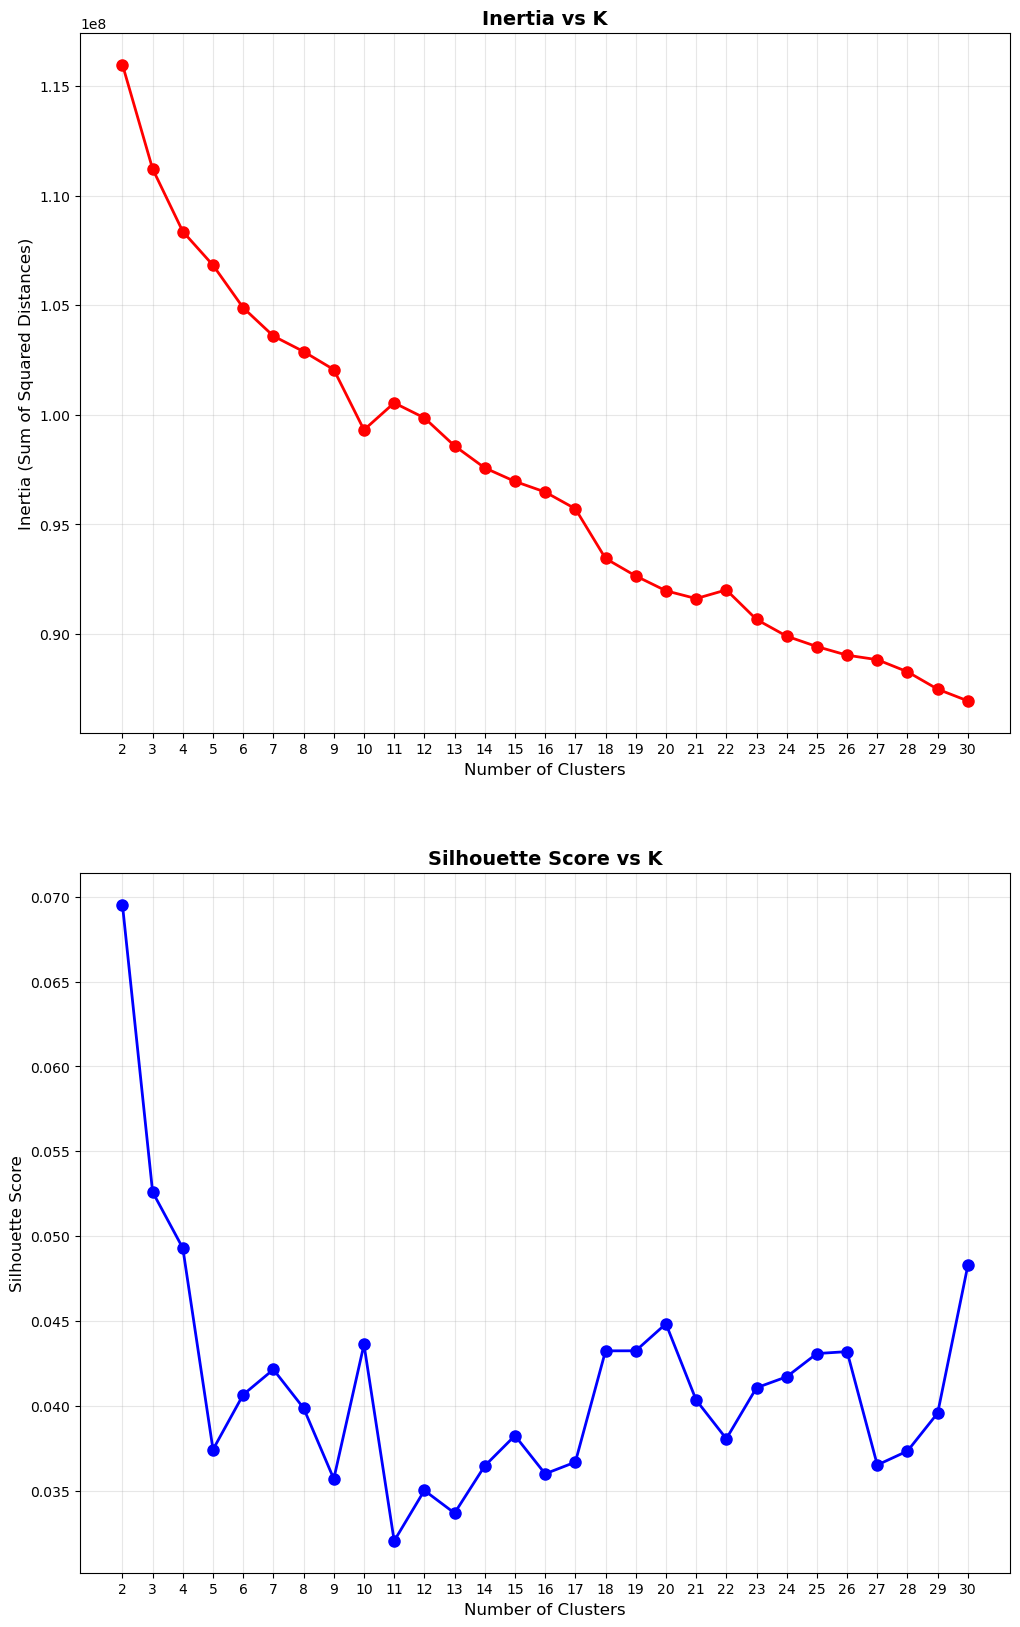

In [23]:
if TEST_CLUSTERS:
    # Investigate the change in within-cluster distance across number of clusters.
    # HINT: Use matplotlib's plot function to visualize this relationship.
    fig, ax = plt.subplots(2, 1, figsize=(12, 20))

    # Plot 1: Inertia
    ax[0].plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
    ax[0].set_xlabel('Number of Clusters', fontsize=12)
    ax[0].set_ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
    ax[0].set_title('Inertia vs K', fontsize=14, fontweight='bold')
    ax[0].set_xticks(k_range)
    ax[0].grid(True, alpha=0.3)

    # Plot 2: Silhouette Score
    ax[1].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
    ax[1].set_xlabel('Number of Clusters', fontsize=12)
    ax[1].set_ylabel('Silhouette Score', fontsize=12)
    ax[1].set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
    ax[1].set_xticks(k_range)
    ax[1].grid(True, alpha=0.3)

    plt.show()

From the results above, we choose a cluster of either 8 or 9, due to the silhouette score peak at k=9, I have opted for 9.

In [24]:
N_CLUSTERS = 10

Now we re-fit KMeans model with this selected number of clusters, to get our final KMeans model for further analysis:

In [25]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.
model_final = KMeans(n_clusters=10, random_state=42).fit(X_pca)

# Get the population clusters:
population_clusters = model_final.predict(X_pca)
print(f"Population Clusters: {population_clusters}")

Population Clusters: [0 2 7 ... 2 6 8]


### Discussion 3.1: Apply Clustering to General Population

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding clustering. Into how many clusters have you decided to segment the population?)

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

Load the Customer Data:

In [26]:
# Load in the customer demographics data.
df_customers_raw = pd.read_csv(DATA_CUSTOMERS, delimiter=';')
print(df_customers_raw.info())
df_customers_raw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191652 entries, 0 to 191651
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               191652 non-null  int64  
 1   ALTERSKATEGORIE_GROB   191652 non-null  int64  
 2   ANREDE_KZ              191652 non-null  int64  
 3   CJT_GESAMTTYP          188439 non-null  float64
 4   FINANZ_MINIMALIST      191652 non-null  int64  
 5   FINANZ_SPARER          191652 non-null  int64  
 6   FINANZ_VORSORGER       191652 non-null  int64  
 7   FINANZ_ANLEGER         191652 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  191652 non-null  int64  
 9   FINANZ_HAUSBAUER       191652 non-null  int64  
 10  FINANZTYP              191652 non-null  int64  
 11  GEBURTSJAHR            191652 non-null  int64  
 12  GFK_URLAUBERTYP        188439 non-null  float64
 13  GREEN_AVANTGARDE       191652 non-null  int64  
 14  HEALTH_TYP             191652 non-nu

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,2,4,1,5.0,5,1,5,1,2,2,2,0,4.0,1,1,20.0,5.0,2.0,2.0,10.0,5.0,1,4,5.0,6,5,2,6,6,7,3,4,1,3,1,1,2,1,3,0.0,0.0,1,3,10.0,2.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,1.0,5.0,1992.0,W,7.0,1,1A,13,2.0,2.0,0.0,0.0,0.0,4.0,3.0,2.0,4.0,4.0,1.0,4.0,3.0,1.0,1201.0,3.0,3.0,1.0,0.0,1.0,5.0,5.0,1.0,2.0,1.0
1,-1,4,1,NaN,5,1,5,1,3,2,2,0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,3,6,2,6,7,5,3,4,1,3,3,2,4,1,3,0.0,0.0,1,3,11.0,3.0,0.0,NaN,NaN,0.0,9.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-1,4,2,2.0,5,1,5,1,4,4,2,0,3.0,1,2,13.0,3.0,1.0,1.0,10.0,5.0,1,4,5.0,2,2,1,3,3,7,7,1,2,7,5,6,4,1,1,0.0,0.0,2,3,6.0,1.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,8.0,1.0,1992.0,W,2.0,5,5D,34,2.0,2.0,0.0,0.0,0.0,3.0,7.0,4.0,1.0,3.0,3.0,3.0,1.0,7.0,433.0,2.0,3.0,3.0,1.0,3.0,3.0,2.0,3.0,5.0,3.0
3,1,4,1,2.0,5,1,5,2,1,2,6,0,10.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,1,3.0,6,5,3,4,7,5,3,4,3,3,3,3,3,4,0,0.0,0.0,1,1,8.0,0.0,0.0,4.0,NaN,NaN,9.0,0.0,NaN,2.0,2.0,1992.0,W,7.0,4,4C,24,3.0,0.0,0.0,0.0,1.0,4.0,7.0,1.0,7.0,4.0,3.0,4.0,2.0,6.0,755.0,3.0,2.0,1.0,0.0,1.0,3.0,4.0,1.0,3.0,1.0
4,-1,3,1,6.0,3,1,4,4,5,2,2,1960,2.0,0,3,31.0,10.0,10.0,5.0,1.0,1.0,1,8,5.0,4,5,4,6,5,6,4,5,5,3,5,2,5,4,1,0.0,0.0,2,1,20.0,4.0,0.0,6.0,2.0,2.0,9.0,7.0,0.0,3.0,1.0,1992.0,W,3.0,7,7B,41,0.0,3.0,2.0,0.0,0.0,3.0,3.0,4.0,4.0,3.0,4.0,3.0,5.0,7.0,513.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,3.0,5.0,1.0


Apply all preprocessing steps:

In [27]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.
df_customers_clean = clean_data(df_customers_raw, az_preprocessor, is_customer_data=True)
print(df_customers_clean.info())
df_customers_clean.head()

Cleaning Customer Data...Transforming...
Dropping Features: ['KBA05_BAUMAX', 'ALTER_HH', 'AGER_TYP', 'KK_KUNDENTYP', 'GEBURTSJAHR', 'TITEL_KZ']
Dropped 6 features
Kept 141713 rows, dropped 49939 rows
Dropping Features: ['SOHO_KZ', 'CAMEO_DEUG_2015', 'NATIONALITAET_KZ', 'LP_LEBENSPHASE_GROB', 'LP_FAMILIE_GROB', 'LP_STATUS_GROB', 'PLZ8_BAUMAX']
Dropped 7 features
MixedFeatureEngineer Encoding...
MixedFeatureEngineer Encoded PRAEGENDE_DECADE from PRAEGENDE_JUGENDJAHRE
MixedFeatureEngineer Encoded PRAEGENDE_MOVEMENT from PRAEGENDE_JUGENDJAHRE
MixedFeatureEngineer Dropped PRAEGENDE_JUGENDJAHRE
MixedFeatureEngineer Encoded CAMEO_WEALTH from CAMEO_INTL_2015
MixedFeatureEngineer Encoded CAMEO_LIFESTAGE from CAMEO_INTL_2015
MixedFeatureEngineer Dropped CAMEO_INTL_2015
MixedFeatureEngineer Encoded LP_LIFE_STAGE from LP_LEBENSPHASE_FEIN
MixedFeatureEngineer Encoded LP_INCOME_LEVEL from LP_LEBENSPHASE_FEIN
MixedFeatureEngineer Encoded LP_IS_INDEPENDENT from LP_LEBENSPHASE_FEIN
MixedFeatureEngineer

,ALTERSKATEGORIE_GROB,ANREDE_KZ,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,ANZ_PERSONEN,ANZ_TITEL,ARBEIT,BALLRAUM,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan,CAMEO_LIFESTAGE,CAMEO_WEALTH,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,EWDICHTE,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,FINANZ_ANLEGER,FINANZ_HAUSBAUER,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_UNAUFFAELLIGER,FINANZ_VORSORGER,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GEBAEUDETYP_RASTER,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_nan,GREEN_AVANTGARDE,HEALTH_TYP,HH_EINKOMMEN_SCORE,INNENSTADT,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,KBA13_ANZAHL_PKW,KKK,KONSUMNAEHE,LP_AGE_CLASS,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_nan,LP_INCOME_LEVEL,LP_IS_HOMEOWNER,LP_IS_INDEPENDENT,LP_LIFE_STAGE_1.0,LP_LIFE_STAGE_2.0,LP_LIFE_STAGE_3.0,LP_LIFE_STAGE_4.0,LP_LIFE_STAGE_5.0,LP_LIFE_STAGE_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_nan,MIN_GEBAEUDEJAHR,MOBI_REGIO,ONLINE_AFFINITAET,ORTSGR_KLS9,OST_WEST_KZ,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_GBZ,PLZ8_HHZ,PRAEGENDE_DECADE,PRAEGENDE_MOVEMENT,REGIOTYP,RELAT_AB,RETOURTYP_BK_S,SEMIO_DOM,SEMIO_ERL,SEMIO_FAM,SEMIO_KAEM,SEMIO_KRIT,SEMIO_KULT,SEMIO_LUST,SEMIO_MAT,SEMIO_PFLICHT,SEMIO_RAT,SEMIO_REL,SEMIO_SOZ,SEMIO_TRADV,SEMIO_VERT,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,VERS_TYP,WOHNDAUER_2008,WOHN_IS_RURAL,WOHN_NEIGHBORHOOD_QUALITY,WOHN_NEW_BUILDING,W_KEIT_KIND_HH,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,4.0,1,1.0,0.0,2.0,0.0,1.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1,2,5,1,2,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1.0,1.0,4.0,2.0,2.0,0.0,0.0,4.0,1201.0,1.0,5.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1992.0,4.0,3.0,2.0,1.0,3.0,3.0,1.0,0.0,5.0,5.0,1950.0,0.0,1.0,1.0,5.0,1,3,5,1,3,4,7,6,2,1,2,6,1,6,0.0,0.0,0.0,1.0,0.0,1.0,9.0,1.0,NaN,NaN,6.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4.0,2,1.0,0.0,1.0,0.0,3.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,1.0,0.0,0.

Impute and Scale:

In [28]:
# Apply the same imputing and scaling
df_customer_scaled = az_preprocessor.impute_and_scale_data(df_customers_clean)
print(df_customer_scaled.info())
df_customer_scaled.head()

Imputing and Scaling Data...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141713 entries, 0 to 141712
Columns: 188 entries, WOHN_NEW_BUILDING to ZABEOTYP_6
dtypes: float64(188)
memory usage: 203.3 MB
None


,WOHN_NEW_BUILDING,VERS_TYP,PRAEGENDE_MOVEMENT,LP_IS_INDEPENDENT,LP_IS_HOMEOWNER,ANREDE_KZ,GREEN_AVANTGARDE,WOHN_IS_RURAL,OST_WEST_KZ,PLZ8_ANTG1,REGIOTYP,RETOURTYP_BK_S,FINANZ_VORSORGER,CAMEO_WEALTH,GEBAEUDETYP_RASTER,WOHN_NEIGHBORHOOD_QUALITY,SEMIO_PFLICHT,FINANZ_SPARER,PLZ8_GBZ,SEMIO_ERL,HH_EINKOMMEN_SCORE,PLZ8_HHZ,FINANZ_HAUSBAUER,HEALTH_TYP,PLZ8_ANTG3,LP_INCOME_LEVEL,KBA05_ANTG3,ALTERSKATEGORIE_GROB,SEMIO_KRIT,LP_AGE_CLASS,KBA05_ANTG1,KKK,SEMIO_SOZ,MOBI_REGIO,FINANZ_MINIMALIST,SEMIO_KAEM,SEMIO_DOM,EWDICHTE,SEMIO_KULT,ARBEIT,ONLINE_AFFINITAET,W_KEIT_KIND_HH,KBA05_ANTG4,BALLRAUM,PLZ8_ANTG2,PLZ8_ANTG4,SEMIO_LUST,SEMIO_REL,KBA05_GBZ,KBA05_ANTG2,INNENSTADT,RELAT_AB,SEMIO_VERT,SEMIO_RAT,WOHNDAUER_2008,SEMIO_TRADV,CAMEO_LIFESTAGE,SEMIO_MAT,KONSUMNAEHE,FINANZ_UNAUFFAELLIGER,SEMIO_FAM,FINANZ_ANLEGER,ORTSGR_KLS9,ANZ_TITEL,KBA13_ANZAHL_PKW,ANZ_HAUSHALTE_AKTIV,ANZ_PERSONEN,ANZ_HH_TITEL,MIN_GEBAEUDEJAHR,PRAEGENDE_DECADE,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_nan,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_nan,LP_LIFE_STAGE_1.0,LP_LIFE_STAGE_2.0,LP_LIFE_STAGE_3.0,LP_LIFE_STAGE_4.0,LP_LIFE_STAGE_5.0,LP_LIFE_STAGE_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_nan,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,0.0,-0.970618,-0.988556,0.0,0.0,-0.702949,1.006918,0.0,0.294954,0.504764,-1.583033,0.921707,0.516284,-1.138266,0.177574,0.232683,-0.720249,-0.517028,1.370603,-1.067752,-1.362158,1.483773,-0.553105,-1.256262,-0.434089,0.593558,-0.394929,0.701623,-0.514382,-0.488938,-0.146368,-1.425674,1.032921,0.283751,0.723184,-1.448639,-1.884846,-1.170620,0.049445,-1.811052,0.018888,0.919517,-0.313948,-0.615709,0.315762,-0.833132,0.907589,-0.813863,0.308802,0.752050,-0.400067,-1.338613,0.457559,-1.348090,0.305941,-1.369195,-0.277232,1.267258,1.292333,0.137016,0.656859,-0.600725,-1.447342,-0.133728,1.576895,-0.278448,-0.193440,-0.1226,-0.343062,-0.663177,5.723396,-0.090728,-0.125749,-0.20804,-0.155292,-0.164075,-0.158783,-0.192742,-0.293056,-0.116699,-0.11256,-0.221507,-0.245975,-0.236509,-0.122436,-0.261232,-0.123354,-0.095734,-0.118671,-0.110058,-0.10598,-0.182050,-0.076383,-0.08677,-0.073526,-0.270061,-0.142799,-0.093763,-0.149202,-0.091162,-0.172804,-0.157282,-0.09218,-0.075348,-0.

In [29]:
# Check that everything is OK
df_customer_scaled.isna().sum().sum()

np.int64(0)

Finally, apply PCA and Clustering to the Customer Data:

In [30]:
# Apply PCA and Clustering (PCA -> Only transform, Kmeans Model -> Only Predict)
df_customers_pca = pca_final.transform(df_customer_scaled)

# Get the customer clusters
customer_clusters = model_final.predict(df_customers_pca)
customer_clusters

array([4, 9, 7, ..., 4, 9, 3], shape=(141713,), dtype=int32)

### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

Reference: https://knowledge.udacity.com/questions/905904

First, we calculate the proportions of population and customer for each cluster:

In [31]:
# Calculate proportions
# Step 1: .value_counts() counts hom many people are in each cluster and divides by the total (normalizing)
# to get percentages.
# Step 2: .sort_index() to sort so we can easily compare
population_proportions = pd.Series(population_clusters).value_counts(normalize=True).sort_index()
customer_proportions = pd.Series(customer_clusters).value_counts(normalize=True).sort_index()

Next, we visualize the proportions:

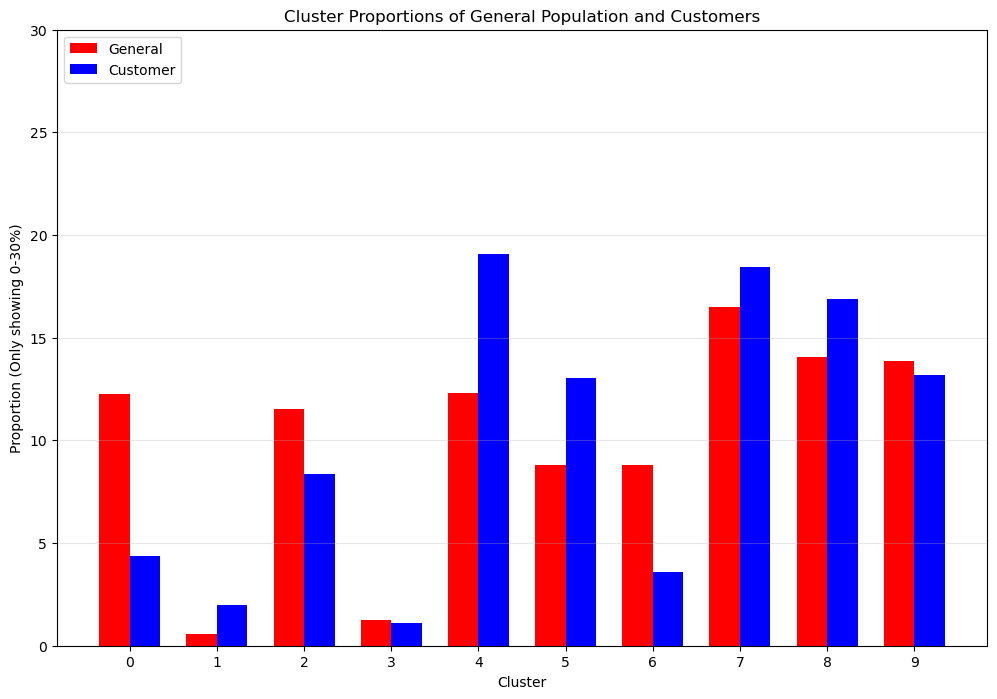

In [32]:
# Plot 1: Proportions of Population and Customers for Each Cluster
width = 0.35
cluster_indexes = np.arange(0, len(np.unique(population_clusters).tolist()))

plt.figure(figsize=(12, 8))
plt.bar(cluster_indexes - width/2, population_proportions * 100, width, color='r', label='General')
plt.bar(cluster_indexes + width/2, customer_proportions * 100, width,  color='b' , label='Customer')

plt.xlabel('Cluster')
plt.ylabel('Proportion (Only showing 0-30%)')

plt.title('Cluster Proportions of General Population and Customers')

plt.xticks(cluster_indexes, np.unique(population_clusters).tolist())
plt.legend(loc='upper left')

plt.yticks(np.arange(0, 31, 5))

plt.grid(True, alpha=0.3, axis='y')

plt.show()

We can also plot the differences between both, to better visualize Over and Under Represented Customers:

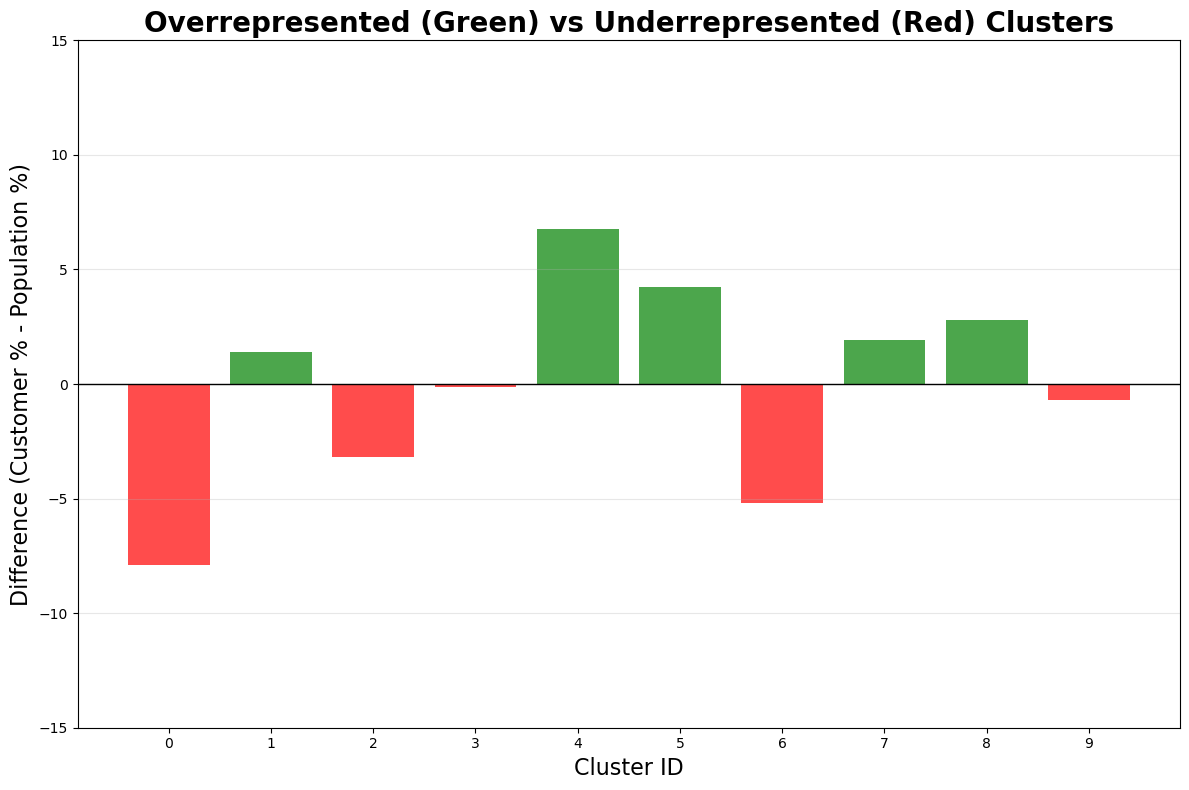

Cluster Analysis:
Cluster 0: Pop=12.27%, Cust=4.35%, Diff=-791.92% UNDERREPRESENTED
Cluster 1: Pop=0.59%, Cust=2.00%, Diff=+141.13% OVERREPRESENTED
Cluster 2: Pop=11.52%, Cust=8.34%, Diff=-317.94% UNDERREPRESENTED
Cluster 3: Pop=1.23%, Cust=1.10%, Diff=-13.10% UNDERREPRESENTED
Cluster 4: Pop=12.32%, Cust=19.10%, Diff=+677.37% OVERREPRESENTED
Cluster 5: Pop=8.80%, Cust=13.02%, Diff=+422.05% OVERREPRESENTED
Cluster 6: Pop=8.80%, Cust=3.61%, Diff=-519.06% UNDERREPRESENTED
Cluster 7: Pop=16.51%, Cust=18.44%, Diff=+192.15% OVERREPRESENTED
Cluster 8: Pop=14.08%, Cust=16.86%, Diff=+277.81% OVERREPRESENTED
Cluster 9: Pop=13.86%, Cust=13.18%, Diff=-68.49% UNDERREPRESENTED


In [33]:
# Plot 2: Difference (Customer % - Population %)
difference = [c - p for c, p in zip(customer_proportions * 100, population_proportions * 100)]
colors = ['g' if x > 0 else 'r' for x in difference]

# Keep a list of each
over_represented_clusters = []
under_represented_clusters = []

plt.figure(figsize=(12, 8))
plt.bar(cluster_indexes, difference, color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Cluster ID', fontsize=16)
plt.ylabel('Difference (Customer % - Population %)', fontsize=16)
plt.title('Overrepresented (Green) vs Underrepresented (Red) Clusters', fontsize=20, fontweight='bold')

plt.xticks(cluster_indexes)
plt.yticks(np.arange(-15, 16, 5))

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

over_represented_clusters = []

# Print detailed comparison
print("Cluster Analysis:")
print("=" * 70)
for i in cluster_indexes:
    diff = difference[i]

    if diff > 0:
        representation = "OVERREPRESENTED"
        over_represented_clusters.append(int(i))

    else:
        representation = "UNDERREPRESENTED"
        under_represented_clusters.append(int(i))

    print(f"Cluster {i}: Pop={population_proportions[i]:.2%}, "
          f"Cust={customer_proportions[i]:.2%}, "
          f"Diff={diff:+.2%} {representation}")

In [34]:
print(f"Overrepresented clusters: {over_represented_clusters}")
print(f"Underrepresented clusters: {under_represented_clusters}")

Overrepresented clusters: [1, 4, 5, 7, 8]
Underrepresented clusters: [0, 2, 3, 6, 9]


Now that we have the proportions and the clusters for each, we can compare and investigate:

For our comparison and investigation:
- The clusters represent different population segments with similar (hopefully) characteristics
- We have the clusters represented in their reduced form (PCA Components)

Therefore, we can create overrepresented and underrepresented customer profiles by:
1. We use the clusters centroids. The centroids represent the mean value of all points assigned to their respective cluster (which for us is a segment)
2. Transforming the cluster centroids to their original data space using PCA ```inverse_transform()```:
3. Split the data into overrepresented and underrepresented groups (this is scaled data)
4. Invert the scaling using the scaler's ```inverse_transform```
5. We can calculate the weights for each cluster, and that way we can get a weighted data frame for each group
6. Once we have the weighted data for each group, we can filter it by the prominent features identified before
7. Finally, we can combine them both into a single dataframe to easily inspect and compare both groups

At the end, we should get profiles for both groups of customers, with the relevant information to make our analysis.

Step 1: Get the cluster centroids:

In [35]:
# Create a DataFrame for the cluster centers (scaled)
# Step 1: Get the centroids
cluster_centroids = model_final.cluster_centers_

Step 2: Convert Centroids into their Original Data Space:

In [36]:
# Step 2: Get the scaled centroids by using PCA.inverse_transform()
cluster_centroids_scaled = pca_final.inverse_transform(cluster_centroids)
cluster_centroids_scaled

array([[ 0.        ,  0.04910204,  0.43594324, ...,  0.48971532,
         0.64900082, -0.04673683],
       [ 0.        , -0.06188756, -0.15516515, ...,  0.01481653,
        -0.08528731, -0.0510606 ],
       [ 0.        , -0.20135089,  0.03281123, ...,  0.50151492,
         0.14383355, -0.04687242],
       ...,
       [ 0.        , -0.08041327,  0.51710915, ..., -0.18905977,
        -0.3524651 , -0.16401344],
       [ 0.        ,  0.21552991,  0.27986706, ..., -0.28011103,
        -0.33611493,  0.66904404],
       [ 0.        ,  0.13886027,  0.35355445, ..., -0.34463108,
        -0.20703241,  0.05164838]], shape=(10, 188))

Step 4: Create Dataframes to Represent Each Group:

In [37]:
# Create the dataframe, using the customer_scaled columns as reference
df_cluster_centroids_scaled = pd.DataFrame(cluster_centroids_scaled, columns=df_customer_scaled.columns)
df_cluster_centroids_scaled.head(10)

,WOHN_NEW_BUILDING,VERS_TYP,PRAEGENDE_MOVEMENT,LP_IS_INDEPENDENT,LP_IS_HOMEOWNER,ANREDE_KZ,GREEN_AVANTGARDE,WOHN_IS_RURAL,OST_WEST_KZ,PLZ8_ANTG1,REGIOTYP,RETOURTYP_BK_S,FINANZ_VORSORGER,CAMEO_WEALTH,GEBAEUDETYP_RASTER,WOHN_NEIGHBORHOOD_QUALITY,SEMIO_PFLICHT,FINANZ_SPARER,PLZ8_GBZ,SEMIO_ERL,HH_EINKOMMEN_SCORE,PLZ8_HHZ,FINANZ_HAUSBAUER,HEALTH_TYP,PLZ8_ANTG3,LP_INCOME_LEVEL,KBA05_ANTG3,ALTERSKATEGORIE_GROB,SEMIO_KRIT,LP_AGE_CLASS,KBA05_ANTG1,KKK,SEMIO_SOZ,MOBI_REGIO,FINANZ_MINIMALIST,SEMIO_KAEM,SEMIO_DOM,EWDICHTE,SEMIO_KULT,ARBEIT,ONLINE_AFFINITAET,W_KEIT_KIND_HH,KBA05_ANTG4,BALLRAUM,PLZ8_ANTG2,PLZ8_ANTG4,SEMIO_LUST,SEMIO_REL,KBA05_GBZ,KBA05_ANTG2,INNENSTADT,RELAT_AB,SEMIO_VERT,SEMIO_RAT,WOHNDAUER_2008,SEMIO_TRADV,CAMEO_LIFESTAGE,SEMIO_MAT,KONSUMNAEHE,FINANZ_UNAUFFAELLIGER,SEMIO_FAM,FINANZ_ANLEGER,ORTSGR_KLS9,ANZ_TITEL,KBA13_ANZAHL_PKW,ANZ_HAUSHALTE_AKTIV,ANZ_PERSONEN,ANZ_HH_TITEL,MIN_GEBAEUDEJAHR,PRAEGENDE_DECADE,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_nan,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_nan,LP_LIFE_STAGE_1.0,LP_LIFE_STAGE_2.0,LP_LIFE_STAGE_3.0,LP_LIFE_STAGE_4.0,LP_LIFE_STAGE_5.0,LP_LIFE_STAGE_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_nan,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,0.0,0.049102,0.435943,1.273252e-15,-1.216717e-15,0.911907,-0.435943,7.191853e-17,-0.101032,-0.710691,0.207503,-0.533202,-0.875080,0.704921,-0.355280,0.289555,1.018129,1.162297,-0.500470,-0.083843,0.755913,0.167984,0.848169,-0.036317,0.732181,-0.548211,0.489052,-0.925195,0.489712,-0.776732,-0.706714,0.125807,-0.452843,-0.786846,-1.399793,0.925595,0.779918,0.637162,-0.034892,0.441515,0.117928,-0.063814,0.477221,-0.369525,0.508402,0.704491,-0.443283,0.743256,-0.689024,0.047985,-0.508600,0.441506,-1.026769,1.213375,-0.337549,0.814595,-0.521232,0.412316,-0.557743,0.824681,-0.079928,1.022345,0.638648,-0.014630,-0.225772,0.402863,-0.271200,0.050533,-0.246924,0.817131,-0.078628,-0.052978,-0.046080,-0.095402,-0.062635,-0.118037,-0.121622,-0.147423,-0.165764,-0.156940,-0.089676,-0.153260,-0.163436,-0.164398,-0.065660,-0.198266,-0.058541,-0.043960,-0.002372,-0.043381,-0.105737,-0.010774,-0.013463,-0.032081,0.048931,-0.027611,0.002189,-0.006021,-0.011012,-0.016902,0.076490,0.11785

We have the centroids, now let's split it into the two groups:

In [38]:
# Create the dataframes for the (centroid) overrepresented and underrepresented customers (scaled)
overrep_scaled = df_cluster_centroids_scaled.iloc[over_represented_clusters]
underrep_scaled = df_cluster_centroids_scaled.iloc[under_represented_clusters]

# We get nparrays in return, convert to DataFrame
df_overrep_scaled = pd.DataFrame(overrep_scaled, columns=df_customer_scaled.columns)
df_underrep_scaled = pd.DataFrame(underrep_scaled, columns=df_customer_scaled.columns)

In [39]:
df_overrep_scaled.head()

,WOHN_NEW_BUILDING,VERS_TYP,PRAEGENDE_MOVEMENT,LP_IS_INDEPENDENT,LP_IS_HOMEOWNER,ANREDE_KZ,GREEN_AVANTGARDE,WOHN_IS_RURAL,OST_WEST_KZ,PLZ8_ANTG1,REGIOTYP,RETOURTYP_BK_S,FINANZ_VORSORGER,CAMEO_WEALTH,GEBAEUDETYP_RASTER,WOHN_NEIGHBORHOOD_QUALITY,SEMIO_PFLICHT,FINANZ_SPARER,PLZ8_GBZ,SEMIO_ERL,HH_EINKOMMEN_SCORE,PLZ8_HHZ,FINANZ_HAUSBAUER,HEALTH_TYP,PLZ8_ANTG3,LP_INCOME_LEVEL,KBA05_ANTG3,ALTERSKATEGORIE_GROB,SEMIO_KRIT,LP_AGE_CLASS,KBA05_ANTG1,KKK,SEMIO_SOZ,MOBI_REGIO,FINANZ_MINIMALIST,SEMIO_KAEM,SEMIO_DOM,EWDICHTE,SEMIO_KULT,ARBEIT,ONLINE_AFFINITAET,W_KEIT_KIND_HH,KBA05_ANTG4,BALLRAUM,PLZ8_ANTG2,PLZ8_ANTG4,SEMIO_LUST,SEMIO_REL,KBA05_GBZ,KBA05_ANTG2,INNENSTADT,RELAT_AB,SEMIO_VERT,SEMIO_RAT,WOHNDAUER_2008,SEMIO_TRADV,CAMEO_LIFESTAGE,SEMIO_MAT,KONSUMNAEHE,FINANZ_UNAUFFAELLIGER,SEMIO_FAM,FINANZ_ANLEGER,ORTSGR_KLS9,ANZ_TITEL,KBA13_ANZAHL_PKW,ANZ_HAUSHALTE_AKTIV,ANZ_PERSONEN,ANZ_HH_TITEL,MIN_GEBAEUDEJAHR,PRAEGENDE_DECADE,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_nan,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_nan,LP_LIFE_STAGE_1.0,LP_LIFE_STAGE_2.0,LP_LIFE_STAGE_3.0,LP_LIFE_STAGE_4.0,LP_LIFE_STAGE_5.0,LP_LIFE_STAGE_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_nan,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
1,0.0,-0.061888,-0.155165,-2.599507e-15,2.518916e-15,-0.039592,0.155165,-5.332192e-15,0.088689,0.065777,-0.034922,0.385595,0.155102,-0.096972,0.018833,-0.064827,-0.103473,-0.209635,0.040608,0.006666,-0.197249,-0.007863,-0.162336,-0.043134,-0.059278,-0.651146,-0.136607,0.091350,-0.071847,0.063943,0.156132,-0.047458,-0.010923,0.174040,0.243734,-0.026635,-0.023006,-0.012559,-0.016810,-0.052302,0.257637,-0.043217,-0.067176,-0.009187,-0.034256,-0.056366,0.051188,-0.101545,0.144650,-0.056385,0.003674,-0.065970,0.090161,-0.089538,0.068193,-0.047391,0.048901,-0.090184,0.026442,-0.122435,-0.052804,-0.199468,-0.023460,0.067759,0.029741,-0.112492,0.200355,-0.019954,0.052637,-0.121527,0.006716,0.001783,0.003134,-0.009429,-0.018260,0.012871,0.018228,-0.005465,0.035945,0.037668,0.003560,0.045601,0.024674,0.017154,0.010153,0.039451,-0.011693,-0.016514,-0.029266,0.006298,-0.000596,0.056994,-0.029820,-0.003224,0.015679,0.025025,-0.014214,-0.008137,0.042176,-0.045391,0.013276,-0.020808,-0

In [40]:
df_underrep_scaled.head()

,WOHN_NEW_BUILDING,VERS_TYP,PRAEGENDE_MOVEMENT,LP_IS_INDEPENDENT,LP_IS_HOMEOWNER,ANREDE_KZ,GREEN_AVANTGARDE,WOHN_IS_RURAL,OST_WEST_KZ,PLZ8_ANTG1,REGIOTYP,RETOURTYP_BK_S,FINANZ_VORSORGER,CAMEO_WEALTH,GEBAEUDETYP_RASTER,WOHN_NEIGHBORHOOD_QUALITY,SEMIO_PFLICHT,FINANZ_SPARER,PLZ8_GBZ,SEMIO_ERL,HH_EINKOMMEN_SCORE,PLZ8_HHZ,FINANZ_HAUSBAUER,HEALTH_TYP,PLZ8_ANTG3,LP_INCOME_LEVEL,KBA05_ANTG3,ALTERSKATEGORIE_GROB,SEMIO_KRIT,LP_AGE_CLASS,KBA05_ANTG1,KKK,SEMIO_SOZ,MOBI_REGIO,FINANZ_MINIMALIST,SEMIO_KAEM,SEMIO_DOM,EWDICHTE,SEMIO_KULT,ARBEIT,ONLINE_AFFINITAET,W_KEIT_KIND_HH,KBA05_ANTG4,BALLRAUM,PLZ8_ANTG2,PLZ8_ANTG4,SEMIO_LUST,SEMIO_REL,KBA05_GBZ,KBA05_ANTG2,INNENSTADT,RELAT_AB,SEMIO_VERT,SEMIO_RAT,WOHNDAUER_2008,SEMIO_TRADV,CAMEO_LIFESTAGE,SEMIO_MAT,KONSUMNAEHE,FINANZ_UNAUFFAELLIGER,SEMIO_FAM,FINANZ_ANLEGER,ORTSGR_KLS9,ANZ_TITEL,KBA13_ANZAHL_PKW,ANZ_HAUSHALTE_AKTIV,ANZ_PERSONEN,ANZ_HH_TITEL,MIN_GEBAEUDEJAHR,PRAEGENDE_DECADE,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_nan,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_nan,LP_LIFE_STAGE_1.0,LP_LIFE_STAGE_2.0,LP_LIFE_STAGE_3.0,LP_LIFE_STAGE_4.0,LP_LIFE_STAGE_5.0,LP_LIFE_STAGE_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_nan,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6
0,0.0,0.049102,0.435943,1.273252e-15,-1.216717e-15,0.911907,-0.435943,7.191853e-17,-0.101032,-0.710691,0.207503,-0.533202,-0.875080,0.704921,-0.355280,0.289555,1.018129,1.162297,-0.500470,-0.083843,0.755913,0.167984,0.848169,-0.036317,0.732181,-0.548211,0.489052,-0.925195,0.489712,-0.776732,-0.706714,0.125807,-0.452843,-0.786846,-1.399793,0.925595,0.779918,0.637162,-0.034892,0.441515,0.117928,-0.063814,0.477221,-0.369525,0.508402,0.704491,-0.443283,0.743256,-0.689024,0.047985,-0.508600,0.441506,-1.026769,1.213375,-0.337549,0.814595,-0.521232,0.412316,-0.557743,0.824681,-0.079928,1.022345,0.638648,-0.014630,-0.225772,0.402863,-0.271200,0.050533,-0.246924,0.817131,-0.078628,-0.052978,-0.046080,-0.095402,-0.062635,-0.118037,-0.121622,-0.147423,-0.165764,-0.156940,-0.089676,-0.153260,-0.163436,-0.164398,-0.065660,-0.198266,-0.058541,-0.043960,-0.002372,-0.043381,-0.105737,-0.010774,-0.013463,-0.032081,0.048931,-0.027611,0.002189,-0.006021,-0.011012,-0.016902,0.076490,0.11785

Step 5: Invert the Scaling:

Now that we have the two groups split, we need to inverse the scaling to get visually important information (so we can compare to the data dictionary codes).

In [41]:
# Inverse scaling
# Get the scaler
scaler = az_preprocessor.scaler

# Inverse transform, get back nparrays
overrep = scaler.inverse_transform(df_overrep_scaled)
underrep = scaler.inverse_transform(df_underrep_scaled)

# We get nparrays in return, convert to DataFrame
df_overrep = pd.DataFrame(overrep, columns=df_customer_scaled.columns)
df_underrep = pd.DataFrame(underrep, columns=df_customer_scaled.columns)

# Set the proper index
df_overrep.index = over_represented_clusters
df_underrep.index = under_represented_clusters

Step 6: Create Weighted Dataframes, so that we can summarize the data and not have to look at each cluster individually:

First we get the cluster weights for each group:

In [42]:
# Get the cluster weights
cluster_weights_over = customer_proportions[df_overrep.index]
cluster_weights_under = customer_proportions[df_underrep.index]

# Normalize them
cluster_weights_over_normalized = cluster_weights_over / cluster_weights_over.sum()
cluster_weights_under_normalized = cluster_weights_under / cluster_weights_under.sum()

print(cluster_weights_over_normalized)
print(cluster_weights_under_normalized)

1    0.028837
4    0.275069
5    0.187621
7    0.265565
8    0.242908
Name: proportion, dtype: float64
0    0.142129
2    0.272742
3    0.036092
6    0.118037
9    0.431001
Name: proportion, dtype: float64


We do not care about ALL the features, so we will filter them out and just focus on the prominent features we identified before

In [43]:
# Now we get a list of the prominent features, as identified in Step 1.4.5
prominent_features_list = [
    (feature, pc_no, "+" if weight > 0 else "-")
    for pc_no, feature_dict in prominent_features.items()
    for feature, weight in feature_dict.items()
]
print(prominent_features_list)

[('FINANZ_MINIMALIST', 0, '+'), ('MOBI_REGIO', 0, '+'), ('KBA05_ANTG1', 0, '+'), ('PLZ8_ANTG1', 0, '+'), ('KBA05_GBZ', 0, '+'), ('ORTSGR_KLS9', 0, '-'), ('PLZ8_ANTG4', 0, '-'), ('CAMEO_WEALTH', 0, '-'), ('PLZ8_ANTG3', 0, '-'), ('HH_EINKOMMEN_SCORE', 0, '-'), ('PRAEGENDE_DECADE', 1, '+'), ('FINANZ_SPARER', 1, '+'), ('FINANZ_UNAUFFAELLIGER', 1, '+'), ('SEMIO_REL', 1, '+'), ('SEMIO_TRADV', 1, '+'), ('SEMIO_ERL', 1, '-'), ('ZABEOTYP_3', 1, '-'), ('LP_AGE_CLASS', 1, '-'), ('FINANZ_VORSORGER', 1, '-'), ('ALTERSKATEGORIE_GROB', 1, '-'), ('ANREDE_KZ', 2, '+'), ('SEMIO_KAEM', 2, '+'), ('SEMIO_DOM', 2, '+'), ('SEMIO_KRIT', 2, '+'), ('SEMIO_ERL', 2, '+'), ('FINANZTYP_5', 2, '-'), ('SEMIO_KULT', 2, '-'), ('SEMIO_SOZ', 2, '-'), ('SEMIO_FAM', 2, '-'), ('SEMIO_VERT', 2, '-')]


Now that we have the cluster weights (normalized) and the prominent features, we create separate weighted profiles for each group:

In [44]:
# Now we can get a combined weighted average profile
# Get the overrepresented one
df_weighted_avg_profile_over = (df_overrep * cluster_weights_over_normalized.values.reshape(-1, 1)).sum(axis=0)
df_weighted_avg_profile_over = df_weighted_avg_profile_over[[x[0] for x in prominent_features_list]]

# Get the underrepresented one
df_weighted_avg_profile_under = (df_underrep * cluster_weights_under_normalized.values.reshape(-1, 1)).sum(axis=0)
df_weighted_avg_profile_under = df_weighted_avg_profile_under[[x[0] for x in prominent_features_list]]

We can now neatly visualize the profiles for both groups:

In [45]:
df_weighted_avg_profile_over

FINANZ_MINIMALIST           4.934623
MOBI_REGIO                  4.146270
KBA05_ANTG1                 2.724791
PLZ8_ANTG1                  2.825757
KBA05_GBZ                   4.048338
ORTSGR_KLS9                 4.659795
PLZ8_ANTG4                  0.346600
CAMEO_WEALTH                2.100987
PLZ8_ANTG3                  1.115273
HH_EINKOMMEN_SCORE          2.504795
PRAEGENDE_DECADE         1954.532828
FINANZ_SPARER               1.066453
FINANZ_UNAUFFAELLIGER       1.565782
SEMIO_REL                   2.990325
SEMIO_TRADV                 2.561342
SEMIO_ERL                   4.757655
ZABEOTYP_3                  0.448086
LP_AGE_CLASS                3.812407
FINANZ_VORSORGER            4.862368
ALTERSKATEGORIE_GROB        3.711989
ANREDE_KZ                   1.118534
SEMIO_KAEM                  2.817487
SEMIO_DOM                   3.424442
SEMIO_KRIT                  3.373506
SEMIO_ERL                   4.757655
FINANZTYP_5                 0.419649
SEMIO_KULT                  4.179501
S

In [46]:
df_weighted_avg_profile_under

FINANZ_MINIMALIST           3.699667
MOBI_REGIO                  3.215475
KBA05_ANTG1                 1.744586
PLZ8_ANTG1                  2.318064
KBA05_GBZ                   3.292906
ORTSGR_KLS9                 5.527778
PLZ8_ANTG4                  0.678536
CAMEO_WEALTH                2.998025
PLZ8_ANTG3                  1.606208
HH_EINKOMMEN_SCORE          3.859294
PRAEGENDE_DECADE         1961.098076
FINANZ_SPARER               1.630668
FINANZ_UNAUFFAELLIGER       2.029745
SEMIO_REL                   3.016362
SEMIO_TRADV                 3.034033
SEMIO_ERL                   5.375382
ZABEOTYP_3                  0.469737
LP_AGE_CLASS                3.432002
FINANZ_VORSORGER            4.402974
ALTERSKATEGORIE_GROB        3.395466
ANREDE_KZ                   1.623863
SEMIO_KAEM                  4.663613
SEMIO_DOM                   4.800456
SEMIO_KRIT                  4.732871
SEMIO_ERL                   5.375382
FINANZTYP_5                 0.259649
SEMIO_KULT                  3.196422
S

In [47]:
# How much data did we not consider?

# Get the high missings subsets
df_pop_high = az_preprocessor.get_high_missing_subset(df_population_raw)
df_cust_high = az_preprocessor.get_high_missing_subset(df_customers_raw)

# Calculate percentages and display results
pct_pop_high = (df_pop_high.shape[0] / df_population_raw.shape[0]) * 100
pct_cust_high = (df_cust_high.shape[0] / df_customers_raw.shape[0]) * 100
print(f"Percent of General Population Data Not Analyzed: {pct_pop_high:.2f}%")
print(f"Percent of Customer Data Analyzed: {pct_cust_high:.2f}%")

Percent of General Population Data Not Analyzed: 10.46%
Percent of Customer Data Analyzed: 26.06%


In [48]:
# combine them:
df_weighted_profile = pd.concat([df_weighted_avg_profile_over, df_weighted_avg_profile_under],  axis=1)

# rename and round the values (for interpretation)
df_profile = df_weighted_profile.rename(columns={0: 'overrepresented', 1: 'underrepresented'}).round()
df_profile.head()

,overrepresented,underrepresented
FINANZ_MINIMALIST,5.0,4.0
MOBI_REGIO,4.0,3.0
KBA05_ANTG1,3.0,2.0
PLZ8_ANTG1,3.0,2.0
KBA05_GBZ,4.0,3.0


Last, but not least, we have to remember that the prominent features were 5 positive and 5 negative for each PC, so for convenience, we re-order the rows by their PC number and sign, so first we show features from PC1 and positives, PC2 and positives, PC3 and positives, and then PC1 and negatives, PC2 and negatives and lastly, PC3 and negatives:

In [49]:
# Define sign ordering for sorting
sign_rank = {"+": 0, "-": 1}

# Build dictionary: feature → sort key
order = {
    feature: (sign_rank[sign], pc)
    for feature, pc, sign in prominent_features_list
}

# Build dictionary: feature → new index label
new_labels = {
    feature: f"{feature}-PC{pc+1}({sign})"
    for feature, pc, sign in prominent_features_list
}

# Reorder and rename index
df_profile_sorted = (
    df_profile
    .loc[sorted(df_profile.index, key=lambda x: order[x])]
    .rename(index=new_labels)
)

In [50]:
# Visualize the sorted DataFrame
df_profile_sorted

,overrepresented,underrepresented
FINANZ_MINIMALIST-PC1(+),5.0,4.0
MOBI_REGIO-PC1(+),4.0,3.0
KBA05_ANTG1-PC1(+),3.0,2.0
PLZ8_ANTG1-PC1(+),3.0,2.0
KBA05_GBZ-PC1(+),4.0,3.0
PRAEGENDE_DECADE-PC2(+),1955.0,1961.0
FINANZ_SPARER-PC2(+),1.0,2.0
FINANZ_UNAUFFAELLIGER-PC2(+),2.0,2.0
SEMIO_REL-PC2(+),3.0,3.0
SEMIO_TRADV-PC2(+),3.0,3.0


We now have a very clear profile of each group! We use this in Discussion 3.3.

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.